**Cell 1: Project Title**

# Netflix Content Classification using Machine Learning

### Objective
Build a machine learning classification model to predict whether a Netflix
title is a **Movie** or **TV Show** based on available metadata.

### Machine Learning Type
- Supervised Learning
- Binary Classification

### Dataset
Netflix Titles Dataset

### Workflow
1. Import Libraries
2. Load Dataset
3. Data Understanding
4. Exploratory Data Analysis
5. Data Cleaning
6. Feature Engineering
7. Train-Test Split
8. Preprocessing
9. Model Training
10. Model Evaluation
11. Model Comparison
12. Feature Importance
13. Prediction on New Data
14. Save the Model

**1. Import Libraries**


**Cell 2: Import Required Libraries**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


**2. Load Dataset**

**Cell 3: Load CSV**

In [7]:
# Load dataset

import pandas as pd

df = pd.read_csv("netflix_titles.csv")

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (8807, 12)


**Cell 4: Preview Dataset**

In [8]:
# Display first five records
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


**Cell 5: Dataset Information**

In [9]:
# Dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


**Cell 6: Statistical Summary**

In [11]:
# Statistical summary for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
release_year,8807.0,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0


**3. Data Understanding**


**Cell 7: Number of Rows and Columns**

In [12]:
rows, columns = df.shape

print(f"Number of Rows    : {rows:,}")
print(f"Number of Columns : {columns}")

Number of Rows    : 8,807
Number of Columns : 12


**Cell 8: Column Names**

In [13]:
# Display all column names
print("Dataset Columns:")
for column in df.columns:
    print(f"- {column}")

Dataset Columns:
- show_id
- type
- title
- director
- cast
- country
- date_added
- release_year
- rating
- duration
- listed_in
- description


**Cell 9: Missing Values**

In [14]:
# Calculate missing values
missing_values = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_percentage = (
    (df.isnull().sum() / len(df)) * 100
).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage.round(2)
})

missing_summary

,Missing Values,Missing Percentage
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03
show_id,0,0.00
type,0,0.00
title,0,0.00
release_year,0,0.00


**4. Exploratory Data Analysis**

**Cell 10: Movie vs TV Show Distribution**

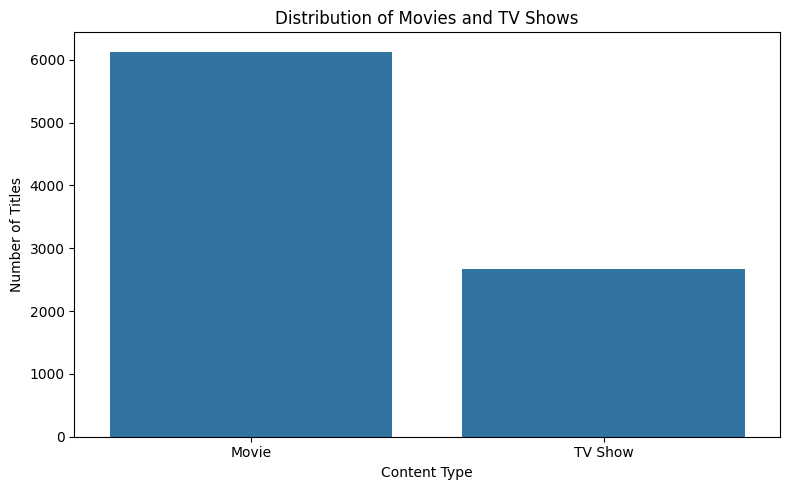

In [15]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="type"
)

plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

**Cell 11: Content Type Percentage**

In [16]:
type_distribution = (
    df["type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(type_distribution)

type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64


**Cell 12: Release Year Distribution**

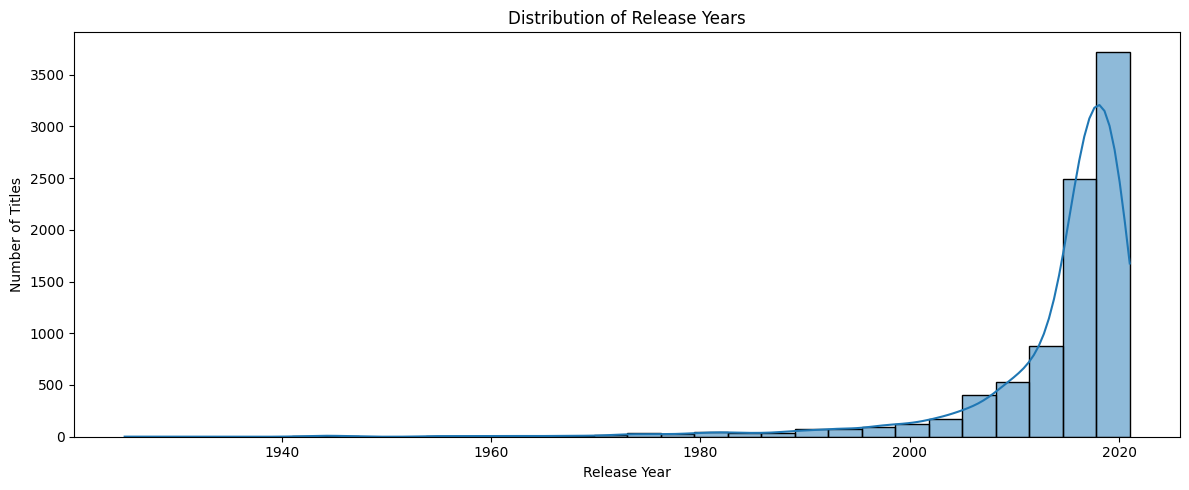

In [17]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x="release_year",
    bins=30,
    kde=True
)

plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

**Cell 13: Ratings Distribution**

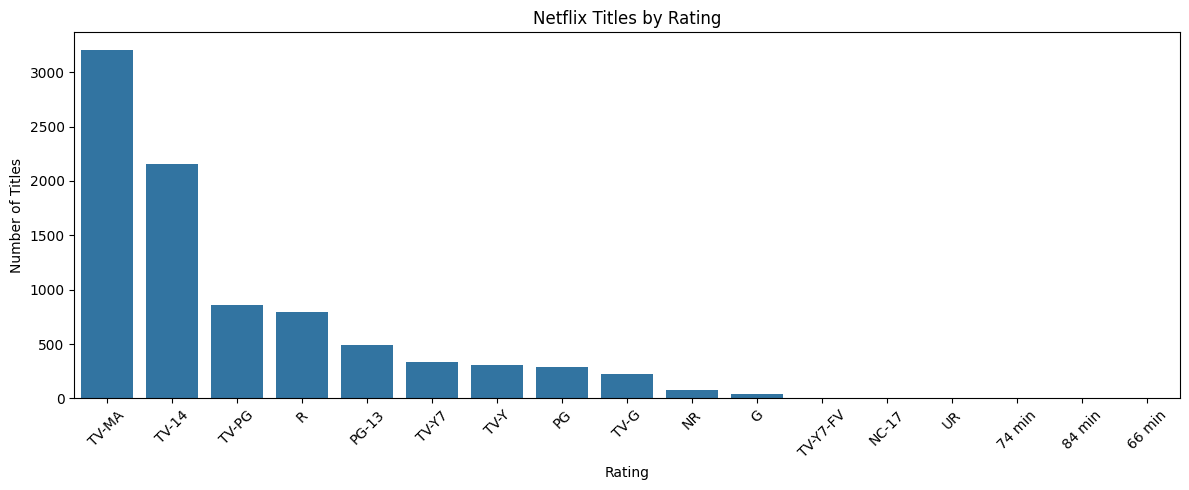

In [18]:
plt.figure(figsize=(12, 5))

sns.countplot(
    data=df,
    x="rating",
    order=df["rating"].value_counts().index
)

plt.title("Netflix Titles by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**5. Data Cleaning**


**Cell 14: Create Working Copy**

In [19]:
# Create a copy to preserve the original dataset
data = df.copy()

print(f"Working dataset shape: {data.shape}")

Working dataset shape: (8807, 12)


**Cell 15: Remove Unnecessary Columns**

For our classification problem, columns like title, description, show ID and director are not necessary for the basic model.

In [20]:
columns_to_drop = [
    "show_id",
    "title",
    "director",
    "cast",
    "description",
    "date_added"
]

data = data.drop(columns=columns_to_drop)

print("Remaining columns:")
print(data.columns.tolist())

Remaining columns:
['type', 'country', 'release_year', 'rating', 'duration', 'listed_in']


**Cell 16: Check Duplicates**

In [21]:
duplicate_count = data.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 602


**Cell 17: Remove Duplicates**

In [22]:
data = data.drop_duplicates()

print(f"Dataset shape after removing duplicates: {data.shape}")

Dataset shape after removing duplicates: (8205, 6)


**6. Feature Engineering**

The duration column contains values such as:

90 min
2 Seasons
1 Season

We can convert it into a numerical feature.

**Cell 18: Extract Duration Value**

In [23]:
# Extract numerical duration
data["duration_value"] = (
    data["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

data[["duration", "duration_value"]].head(10)

,duration,duration_value
0,90 min,90.0
1,2 Seasons,2.0
2,1 Season,1.0
3,1 Season,1.0
4,2 Seasons,2.0
5,1 Season,1.0
6,91 min,91.0
7,125 min,125.0
8,9 Seasons,9.0
9,104 min,104.0


**Cell 19: Create Duration Type**

In [24]:
# Identify whether duration is measured in minutes or seasons
data["duration_type"] = np.where(
    data["duration"].str.contains("Season", na=False),
    "Seasons",
    "Minutes"
)

data[["duration", "duration_value", "duration_type"]].head(10)

,duration,duration_value,duration_type
0,90 min,90.0,Minutes
1,2 Seasons,2.0,Seasons
2,1 Season,1.0,Seasons
3,1 Season,1.0,Seasons
4,2 Seasons,2.0,Seasons
5,1 Season,1.0,Seasons
6,91 min,91.0,Minutes
7,125 min,125.0,Minutes
8,9 Seasons,9.0,Seasons
9,104 min,104.0,Minutes


**Cell 20: Drop Original Duration**

In [25]:
data = data.drop(columns=["duration"])

data.head()

,type,country,release_year,rating,listed_in,duration_value,duration_type
0,Movie,United States,2020,PG-13,Documentaries,90.0,Minutes
1,TV Show,South Africa,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries",2.0,Seasons
2,TV Show,NaN,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",1.0,Seasons
3,TV Show,NaN,2021,TV-MA,"Docuseries, Reality TV",1.0,Seasons
4,TV Show,India,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",2.0,Seasons


**7. Define Features and Target**


**Cell 21: Separate X and y**

In [26]:
# Target variable
target_column = "type"

X = data.drop(columns=[target_column])
y = data[target_column]

print("Feature shape :", X.shape)
print("Target shape  :", y.shape)

Feature shape : (8205, 6)
Target shape  : (8205,)


**Cell 22: Target Distribution**

In [27]:
print("Target Distribution:")
print(y.value_counts())

Target Distribution:
type
Movie      5958
TV Show    2247
Name: count, dtype: int64


**8. Train-Test Split**


**Cell 23: Split Dataset**

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Testing samples  : {X_test.shape[0]:,}")

Training samples : 6,564
Testing samples  : 1,641


**9. Identify Feature Types**


**Cell 24: Numerical and Categorical Features**

In [29]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['release_year', 'duration_value']

Categorical Features:
['country', 'rating', 'listed_in', 'duration_type']


**10. Build Preprocessing Pipeline**

This is an important professional practice.

Instead of manually preprocessing training and testing data separately, we use a Pipeline + ColumnTransformer.

**Cell 25: Preprocessing Pipeline**

In [30]:
# Numerical preprocessing
numerical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


**11. Model 1: Logistic Regression**

**Cell 26: Train Logistic Regression**

In [31]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


**Cell 27: Logistic Regression Predictions**

In [32]:
y_pred_logistic = logistic_model.predict(X_test)

print(y_pred_logistic[:20])

['Movie' 'TV Show' 'TV Show' 'Movie' 'Movie' 'TV Show' 'TV Show' 'Movie'
 'Movie' 'Movie' 'TV Show' 'Movie' 'Movie' 'TV Show' 'Movie' 'TV Show'
 'Movie' 'Movie' 'Movie' 'Movie']


**Cell 28: Logistic Regression Evaluation**

In [33]:
accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic
)

precision_logistic = precision_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

recall_logistic = recall_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

f1_logistic = f1_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

print("Logistic Regression Performance")
print("-" * 40)
print(f"Accuracy  : {accuracy_logistic:.4f}")
print(f"Precision : {precision_logistic:.4f}")
print(f"Recall    : {recall_logistic:.4f}")
print(f"F1 Score  : {f1_logistic:.4f}")

Logistic Regression Performance
----------------------------------------
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000


**Cell 29: Classification Report**

In [34]:
print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1192
     TV Show       1.00      1.00      1.00       449

    accuracy                           1.00      1641
   macro avg       1.00      1.00      1.00      1641
weighted avg       1.00      1.00      1.00      1641



**12. Confusion Matrix**

**Cell 30: Logistic Regression Confusion Matrix**

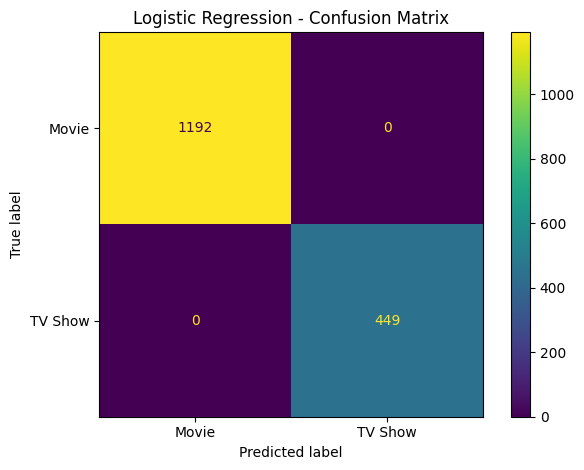

In [35]:
cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=logistic_model.classes_
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

**13. Model 2: Decision Tree**

**Cell 31: Train Decision Tree**

In [36]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=10,
                random_state=RANDOM_STATE
            )
        )
    ]
)

decision_tree_model.fit(
    X_train,
    y_train
)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


**Cell 32: Decision Tree Evaluation**

In [37]:
y_pred_tree = decision_tree_model.predict(X_test)

accuracy_tree = accuracy_score(
    y_test,
    y_pred_tree
)

precision_tree = precision_score(
    y_test,
    y_pred_tree,
    average="weighted"
)

recall_tree = recall_score(
    y_test,
    y_pred_tree,
    average="weighted"
)

f1_tree = f1_score(
    y_test,
    y_pred_tree,
    average="weighted"
)

print("Decision Tree Performance")
print("-" * 40)
print(f"Accuracy  : {accuracy_tree:.4f}")
print(f"Precision : {precision_tree:.4f}")
print(f"Recall    : {recall_tree:.4f}")
print(f"F1 Score  : {f1_tree:.4f}")

Decision Tree Performance
----------------------------------------
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000


**14. Model 3: Random Forest**

**Cell 33: Train Random Forest**

In [39]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=15,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


**Cell 34: Random Forest Evaluation**

In [40]:
y_pred_rf = random_forest_model.predict(X_test)

accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

print("Random Forest Performance")
print("-" * 40)
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")

Random Forest Performance
----------------------------------------
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000


**15. Compare Models**

**Cell 35: Model Comparison**

In [41]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_tree,
        accuracy_rf
    ],
    "Precision": [
        precision_logistic,
        precision_tree,
        precision_rf
    ],
    "Recall": [
        recall_logistic,
        recall_tree,
        recall_rf
    ],
    "F1 Score": [
        f1_logistic,
        f1_tree,
        f1_rf
    ]
})

model_comparison = model_comparison.sort_values(
    by="F1 Score",
    ascending=False
)

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0


**Cell 36: Visual Model Comparison**

<Figure size 1000x600 with 0 Axes>

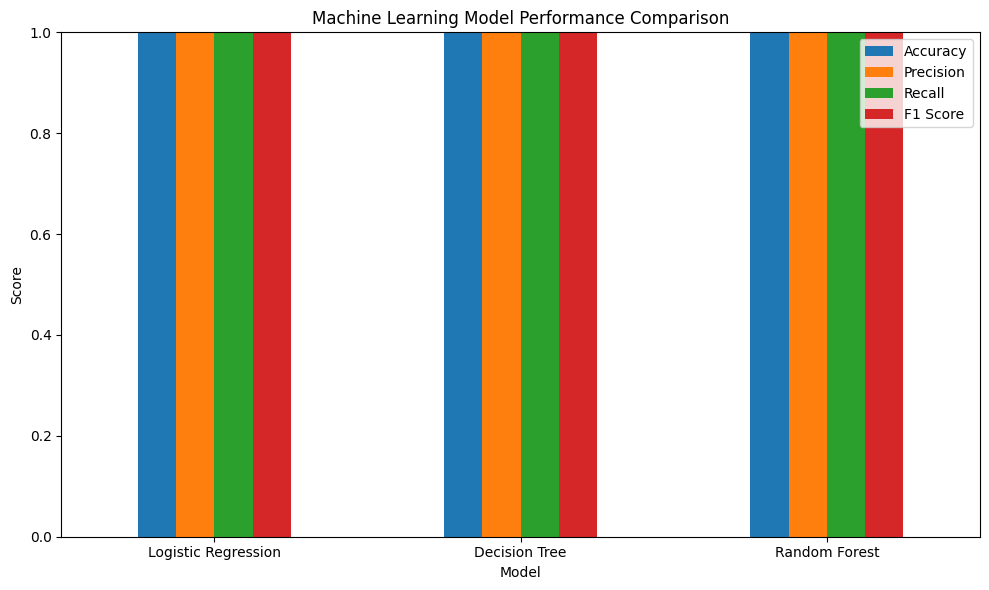

In [42]:
plt.figure(figsize=(10, 6))

model_comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

**16. Best Model**

**Cell 37: Select Best Model**

In [43]:
best_model_name = model_comparison.iloc[0]["Model"]

print(f"Best Model: {best_model_name}")

Best Model: Logistic Regression


**17. Detailed Evaluation of Random Forest**

**Cell 38: Classification Report**

In [44]:
print("Random Forest Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

Random Forest Classification Report
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1192
     TV Show       1.00      1.00      1.00       449

    accuracy                           1.00      1641
   macro avg       1.00      1.00      1.00      1641
weighted avg       1.00      1.00      1.00      1641



**Cell 39: Confusion Matrix**

<Figure size 700x500 with 0 Axes>

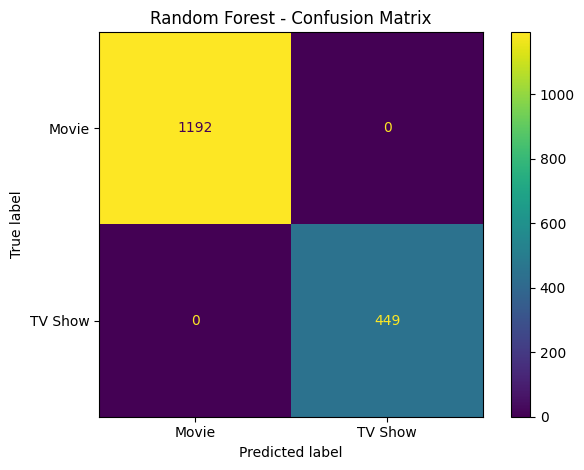

In [45]:
plt.figure(figsize=(7, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

**18. Feature Importance**

Random Forest can help us understand which features contribute most to the prediction.

**Cell 40: Extract Feature Importance**

In [46]:
# Access fitted preprocessing pipeline
preprocessor_fitted = random_forest_model.named_steps[
    "preprocessor"
]

# Get transformed feature names
feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

# Get feature importance
importances = (
    random_forest_model
    .named_steps["classifier"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
1127,categorical__duration_type_Minutes,0.280881
1128,categorical__duration_type_Seasons,0.269983
1,numerical__duration_value,0.219068
1043,categorical__listed_in_Kids' TV,0.026337
640,categorical__rating_R,0.014507
877,"categorical__listed_in_Crime TV Shows, Interna...",0.013923
1054,"categorical__listed_in_Kids' TV, TV Comedies",0.009695
0,numerical__release_year,0.009085
1017,"categorical__listed_in_International TV Shows,...",0.007644
1033,"categorical__listed_in_International TV Shows,...",0.007539


**Cell 41: Feature Importance Visualization**

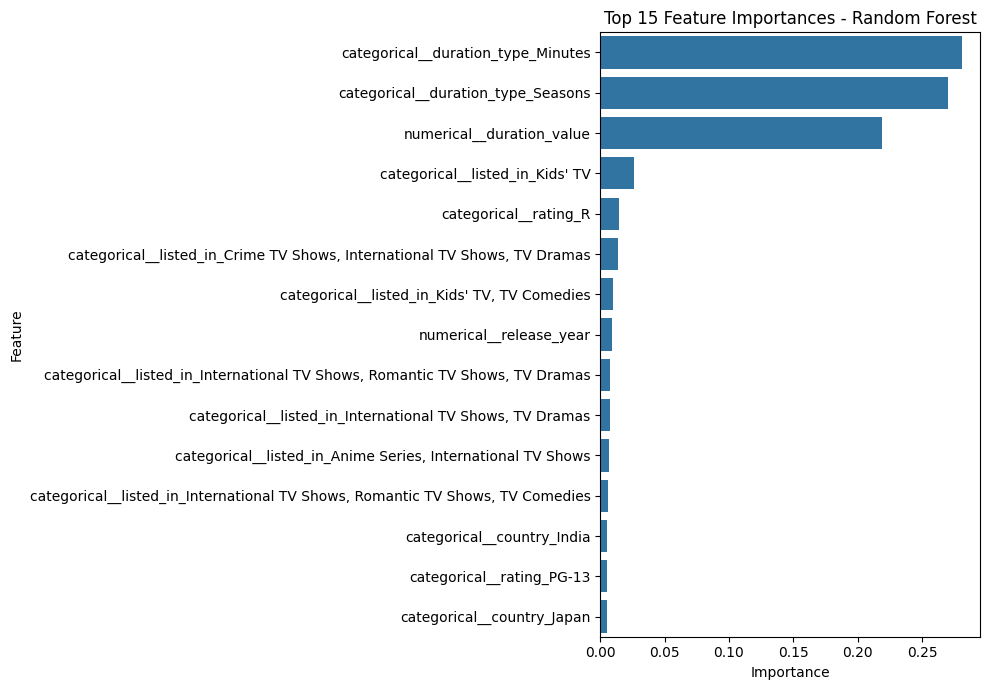

In [47]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

**19. Make Predictions on New Data**

**Cell 42: Example Prediction**

In [48]:
# Create a sample Netflix title
new_title = pd.DataFrame({
    "country": ["India"],
    "release_year": [2024],
    "rating": ["TV-MA"],
    "listed_in": ["International TV Shows, TV Dramas"],
    "duration_value": [2],
    "duration_type": ["Seasons"]
})

prediction = random_forest_model.predict(
    new_title
)

print(f"Predicted Content Type: {prediction[0]}")

Predicted Content Type: TV Show


**20. Prediction Probability**

**Cell 43: Prediction Probability**

In [49]:
prediction_probability = (
    random_forest_model
    .predict_proba(new_title)
)

probability_df = pd.DataFrame(
    prediction_probability,
    columns=random_forest_model.classes_
)

probability_df

,Movie,TV Show
0,0.099453,0.900547


**21. Save Model**

A professional ML project should save the trained model so it can later be used by an application.

**Cell 44: Save Model**

In [50]:
import joblib

model_path = "netflix_content_classifier.pkl"

joblib.dump(
    random_forest_model,
    model_path
)

print(f"Model saved successfully: {model_path}")

Model saved successfully: netflix_content_classifier.pkl


**22. Load Saved Model**

**Cell 45: Load Model**

In [51]:
loaded_model = joblib.load(
    "netflix_content_classifier.pkl"
)

print("Model loaded successfully.")

Model loaded successfully.


**Cell 46: Test Loaded Model**

In [52]:
loaded_prediction = loaded_model.predict(
    new_title
)

print(
    f"Prediction from loaded model: "
    f"{loaded_prediction[0]}"
)

Prediction from loaded model: TV Show


**24. Cross-Validation**

Cross-validation gives us a more reliable estimate of model performance than relying on only one train-test split.

**Cell 48: Import Cross-Validation**

In [53]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

print("Cross-validation libraries imported successfully.")

Cross-validation libraries imported successfully.


**Cell 49: Define Cross-Validation Strategy**

In [54]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("5-Fold Stratified Cross-Validation configured.")

5-Fold Stratified Cross-Validation configured.


**Cell 50: Cross-Validate Random Forest**

In [55]:
cv_scores = cross_val_score(
    random_forest_model,
    X,
    y,
    cv=cv_strategy,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Cross-Validation F1 Scores:")
print(cv_scores)

print(f"\nMean F1 Score : {cv_scores.mean():.4f}")
print(f"Std Deviation : {cv_scores.std():.4f}")

Cross-Validation F1 Scores:
[1. 1. 1. 1. 1.]

Mean F1 Score : 1.0000
Std Deviation : 0.0000


What this tells you
Mean F1 Score

is the average performance across all five folds.

Std Deviation

shows how stable the model is.

Lower standard deviation generally means more consistent performance.

**25. Hyperparameter Tuning**

Now we'll improve Random Forest using GridSearchCV.

**Cell 51: Import GridSearchCV**

In [56]:
from sklearn.model_selection import GridSearchCV

print("GridSearchCV imported successfully.")

GridSearchCV imported successfully.


**Cell 52: Define Hyperparameters**

In [57]:
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [10, 15, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

print("Hyperparameter grid created.")

Hyperparameter grid created.


**Cell 53: Create Grid Search**

In [58]:
grid_search = GridSearchCV(
    estimator=random_forest_model,
    param_grid=param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

print("Grid search initialized.")

Grid search initialized.


**Cell 54: Train Grid Search**

In [59]:
grid_search.fit(
    X_train,
    y_train
)

print("Hyperparameter tuning completed.")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Hyperparameter tuning completed.


**Cell 55: Best Parameters**

In [60]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


**Cell 56: Best Cross-Validation Score**

In [61]:
print(
    f"Best Cross-Validation F1 Score: "
    f"{grid_search.best_score_:.4f}"
)

Best Cross-Validation F1 Score: 1.0000
